In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import lombscargle
import scipy.stats as stats

from datetime import datetime, timedelta

In [2]:
# scp -r compute@10.193.27.73:~/realtime-gnssrefl/control/logs/ /home/jortvd/Documents/GitKraken/realtime-gnssrefl/analysis/results

In [2]:
# Load the data
records = pd.read_csv(
    './logs/data.csv',
    header=0,
    names=["bin_idx","time", "id", "satellite", "network", "band", "elevation", "azimuth", "snr"]
)
measurements = pd.read_csv(
    './logs/measurement.csv',
    header=0,
    names=["idx", "uid", "mean", "std", "num_seen", "start_time", "end_time", "lat", "lon"]
)
observations = pd.read_csv(
    './logs/observation.csv',
    header=0,
    names=["meas_idx", "obs_idx", "sat_id", "start_time", "end_time", "used", "max_rh", "max_amp", "mean_amp", "num_recs"]
)
sectors = pd.read_csv(
    './logs/sector.csv',
    header=0,
    names=["idx", "uid", "state", "midpoint_idx", "measurement_idx", "start_bin_idx", "start_time", "lat", "lon"]
)

In [5]:
NUM_MEASUREMENTS_PER_DAY = 6
IDX_MEASUREMENT_ON_DAY = 5

timestamp = datetime.now().timestamp()
epoch = datetime(1970, 1, 1)
dt = epoch + timedelta(seconds=timestamp)
days = (dt - epoch).days

print("Now on measurement:", days * NUM_MEASUREMENTS_PER_DAY + IDX_MEASUREMENT_ON_DAY)

Now on measurement: 122267


In [6]:
# Get bins for the measured sectors
BINS_PER_SECTOR = 25
NUM_BINS = 50

def sector_uid_to_bins(uid):
    start_bin = (uid * BINS_PER_SECTOR) % NUM_BINS
    return [i for i in range(start_bin, start_bin + BINS_PER_SECTOR)]

for _, row in measurements.iterrows():
    uid_int = int(row['uid'])
    if uid_int <= 0:
        continue
    bins = sector_uid_to_bins(uid_int)
    print(f'Sector {uid_int} covers bins {bins}')

bins = sector_uid_to_bins(122267)
print(f'Sector {122267} covers bins {bins}')

Sector 142635 covers bins [25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49]
Sector 631666 covers bins [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]
Sector 20377 covers bins [25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49]
Sector 631661 covers bins [25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49]
Sector 631662 covers bins [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]
Sector 631663 covers bins [25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49]
Sector 40754 covers bins [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]
Sector 122267 covers bins [25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49]


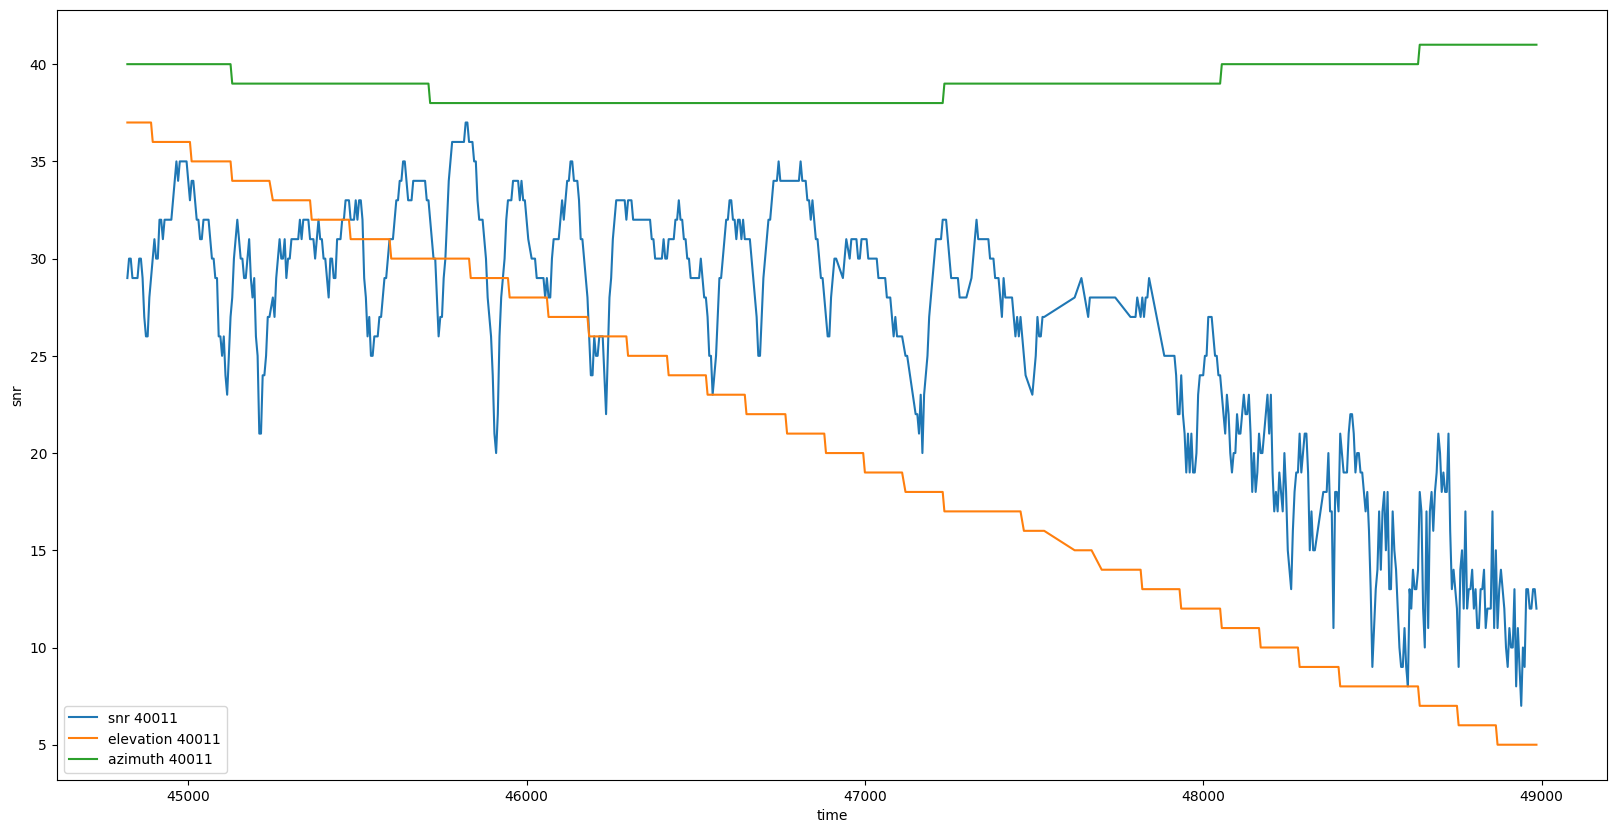

In [22]:
# Plot X over Y for specific bins
X_AXIS = 'time'
Y_AXIS = 'snr'
BINS = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]
N_MAX = 1  # 0 for all

plt.figure(figsize=(20, 10))
records_in_time = records[records['bin_idx'].isin(BINS)]
for i, id_val in enumerate(records_in_time['id'].unique()):
    if id_val == 0:
        continue
    # if N_MAX != 0 and i >= N_MAX:
    #     break
    if id_val != 40011:
        continue
    id_data = records_in_time[records_in_time['id'] == id_val]
    plt.plot(id_data[X_AXIS], id_data[Y_AXIS], label=f'snr {id_val}')
    plt.plot(id_data[X_AXIS], id_data['elevation'], label=f'elevation {id_val}')
    plt.plot(id_data[X_AXIS], id_data['azimuth'], label=f'azimuth {id_val}')

plt.xlabel(X_AXIS)
plt.ylabel(Y_AXIS)
plt.legend()
plt.show()

In [8]:
def lombscargle_uniform(x, y, f0, df, m):
    """
    Ultra-fast Lomb-Scargle for a uniform frequency grid:
      f_k = f0 + k*df, k = 0..m-1
    Returns an array of length m with the powers.

    Notes:
    - Closely follows the original structure (τ-rotation + angle addition).
    - No scratch buffers, no fixed-point quantization, no yielding.
    - Uses float32 arrays for speed/consistency.
    """
    x = np.asarray(x, dtype=np.float32)
    y = np.asarray(y, dtype=np.float32)
    m = int(m)
    if m <= 0:
        return np.zeros(0, dtype=np.float32)

    TWO_PI = np.float32(2.0 * np.pi)
    EPS = np.float32(1.0e-7)

    # keep only finite pairs
    mask = np.isfinite(x) & np.isfinite(y)
    if not np.any(mask):
        return np.zeros(m, dtype=np.float32)

    t = x[mask]
    yy = y[mask]
    yy = yy - yy.mean(dtype=np.float64).astype(np.float32)  # center

    omega0 = np.float32(TWO_PI * f0)
    domega = np.float32(TWO_PI * df)

    # initial sin/cos(ω0 t) and constant sin/cos(Δω t)
    a0 = omega0 * t
    s_w = np.sin(a0, dtype=np.float32)
    c_w = np.cos(a0, dtype=np.float32)

    d = domega * t
    s_d = np.sin(d, dtype=np.float32)
    c_d = np.cos(d, dtype=np.float32)

    out = np.empty(m, dtype=np.float32)

    for k in range(m):
        # --- Pass 1: compute tau from current sin/cos
        s2 = np.sum(2.0 * s_w * c_w, dtype=np.float64).astype(np.float32)
        c2 = np.sum(c_w * c_w - s_w * s_w, dtype=np.float64).astype(np.float32)
        omega_tau = np.float32(0.5) * np.arctan2(s2, c2).astype(np.float32)
        s_tau = np.sin(omega_tau, dtype=np.float32)
        c_tau = np.cos(omega_tau, dtype=np.float32)

        # --- Pass 2: rotate by τ and accumulate
        s_shift = s_w * c_tau - c_w * s_tau
        c_shift = c_w * c_tau + s_w * s_tau

        yc = np.dot(yy.astype(np.float64), c_shift.astype(np.float64))
        ys = np.dot(yy.astype(np.float64), s_shift.astype(np.float64))
        cc = np.dot(c_shift.astype(np.float64), c_shift.astype(np.float64))
        ss = np.dot(s_shift.astype(np.float64), s_shift.astype(np.float64))

        pc = (yc * yc) / cc if cc > EPS else 0.0
        ps = (ys * ys) / ss if ss > EPS else 0.0
        out[k] = 0.5 * (pc + ps)

        # --- Advance (s_w, c_w) to next frequency using angle addition
        if k + 1 < m:
            s_next = s_w * c_d + c_w * s_d
            c_next = c_w * c_d - s_w * s_d
            s_w, c_w = s_next, c_next

    return out.astype(np.float32)

def gauss_solve(a, b, n, eps=1e-6):
    """
    In-place solve A x = b via Gaussian elimination with partial pivoting.
    a: (N,N) array (only top-left n×n used)
    b: (N,)   array (only first n used)
    Returns True on success, False if a near-singular pivot is found.
    """
    a = np.asarray(a)
    b = np.asarray(b)
    # Forward elimination
    for k in range(n):
        # pivot row r with max |a[r,k]|
        r = k + np.argmax(np.abs(a[k:n, k]))
        maxv = abs(a[r, k])
        if maxv < eps:
            return False
        if r != k:
            a[[k, r], k:n] = a[[r, k], k:n]
            b[[k, r]] = b[[r, k]]
        pivot = a[k, k]
        # eliminate
        for i in range(k + 1, n):
            f = a[i, k] / pivot
            a[i, k + 1:n] -= f * a[k, k + 1:n]
            a[i, k] = 0.0
            b[i] -= f * b[k]
    # Back substitution
    for i in range(n - 1, -1, -1):
        s = b[i] - np.dot(a[i, i + 1:n], b[i + 1:n])
        piv = a[i, i]
        if abs(piv) < eps:
            return False
        b[i] = s / piv
    return True

def polyfit_and_smooth(x, y, deg=3):
    """
    Fit a polynomial (default degree 3) to (x,y) via least squares and overwrite y
    with fitted values at each finite x. Non-finite (x,y) pairs are ignored in fitting,
    and non-finite x entries are left unchanged on write-back.
    Returns the effective degree used (min(deg, valid_points-1)).
    """
    x = np.asarray(x, dtype=np.float32)
    y = np.asarray(y, dtype=np.float32).copy()
    assert x.shape == y.shape

    # keep only finite pairs for fitting
    mask = np.isfinite(x) & np.isfinite(y)
    if not np.any(mask):
        return 0

    t = x[mask].astype(np.float64)  # accumulate in float64 for stability
    yy = y[mask].astype(np.float64)
    valid = t.size

    eff_deg = min(int(deg), max(0, valid - 1))
    if eff_deg == 0:
        # constant fit: mean of y over valid samples
        a0 = yy.mean()
        y[np.isfinite(x)] = a0.astype(np.float32)
        return 0

    # Build power sums s[k] = sum t^k, k=0..2*deg and bt[i] = sum y*t^i, i=0..deg
    maxk = 2 * deg
    s = np.zeros(maxk + 1, dtype=np.float64)
    bt = np.zeros(deg + 1, dtype=np.float64)
    for xi, yi in zip(t, yy):
        p = 1.0
        for k in range(maxk + 1):
            s[k] += p
            p *= xi
        p = 1.0
        for i in range(deg + 1):
            bt[i] += yi * p
            p *= xi

    n = eff_deg + 1
    # Normal equations: A[i,j] = s[i+j], b[i] = bt[i]
    A = np.fromfunction(lambda i, j: s[(i + j).astype(int)], (n, n), dtype=int).astype(np.float64)
    bvec = bt[:n].copy()

    ok = gauss_solve(A, bvec, n)
    if not ok:
        # fallback: constant fit
        a0 = yy.mean()
        y[np.isfinite(x)] = a0.astype(np.float32)
        return 0

    # Evaluate polynomial at each finite x using Horner's method
    coeffs = bvec  # c0..c_n-1
    fx_mask = np.isfinite(x)
    xf = x[fx_mask].astype(np.float64)
    acc = np.full_like(xf, coeffs[n - 1], dtype=np.float64)
    for k in range(n - 2, -1, -1):
        acc = acc * xf + coeffs[k]
    y[fx_mask] = acc.astype(np.float32)

    return y

Satellite 10005 rh = 5.04 m, p2m 65.02 (0.06669192016124725, 0.001025640987791121), #620, dE 32.00°, μE 24.07°, μAz 198.99°
Skipping satellite 10012 due to low elevation change (1 < 8)
Skipping satellite 10018 due to low elevation change (0 < 8)
Satellite 10020 rh = 5.04 m, p2m 56.98 (0.05843944102525711, 0.0010256411042064428), #580, dE 20.00°, μE 14.82°, μAz 187.15°
Satellite 10021 rh = 5.04 m, p2m 79.98 (0.08202894032001495, 0.001025640987791121), #701, dE 26.00°, μE 17.46°, μAz 177.19°
Satellite 10024 rh = 5.10 m, p2m 63.91 (0.0655459463596344, 0.001025640987791121), #794, dE 35.00°, μE 22.01°, μAz 257.53°
Skipping satellite 10049 due to low elevation change (0 < 8)
Satellite 20021 rh = 4.92 m, p2m 66.55 (0.06825685501098633, 0.001025640987791121), #773, dE 23.00°, μE 15.98°, μAz 193.13°
Skipping satellite 20027 due to low elevation change (1 < 8)
Satellite 20033 rh = 5.02 m, p2m 51.48 (0.052795808762311935, 0.001025640987791121), #685, dE 17.00°, μE 13.25°, μAz 253.80°
Satellite 4

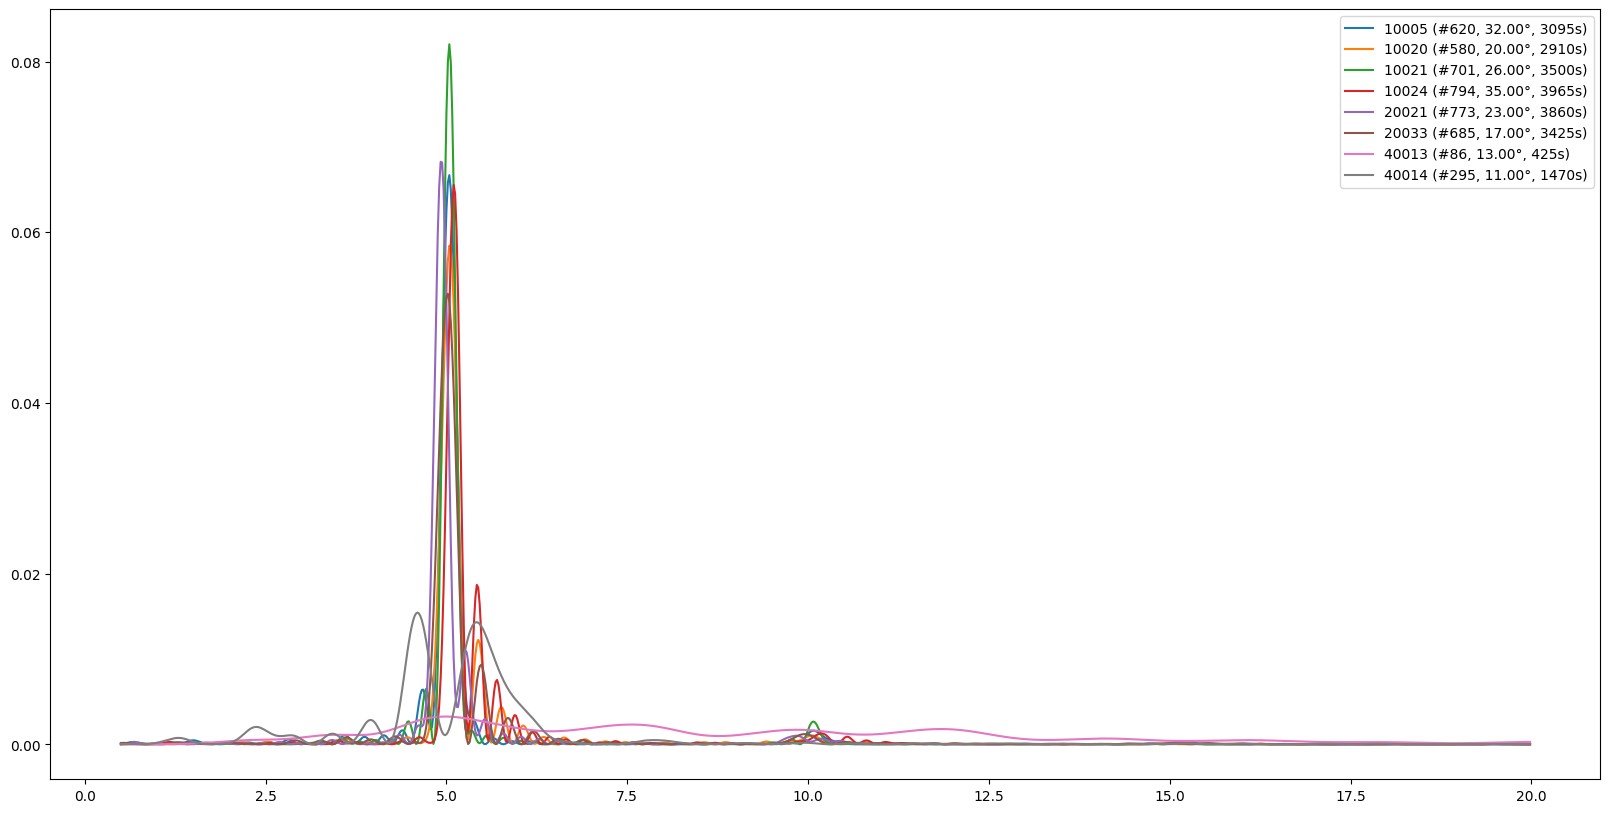

In [25]:
BINS = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]
QC_MIN_ELEV_DIFF = 8  # degrees
METHOD_NEW = True
IMPL_PICO = True

def compute_cf(network):
    wavelength = 299_792_458 / {
        0: 1575.42e6,
        1: 1603.69e6,
        2: 1575.42e6,
        3: 1561.098e6,
        4: 1575.42e6
    }.get(network, 1.0)
    return wavelength / 2.0

plt.figure(figsize=(20, 10))
grouped = records[(records['bin_idx'].isin(BINS)) & (records['azimuth'] >= 160) & (records['azimuth'] <= 280)].groupby('id')
# grouped = records[records['bin_idx'].isin(BINS)].groupby('id')

measurements = []

for sat, group in grouped:
    if sat == 0:
        print(f"Skipping {sat}")
        continue

    min_elev = group['elevation'].min()
    max_elev = group['elevation'].max()

    if max_elev - min_elev < QC_MIN_ELEV_DIFF:
        print(f"Skipping satellite {sat} due to low elevation change ({max_elev - min_elev} < {QC_MIN_ELEV_DIFF})")
        continue

    t = group["time"]
    x = group["elevation"]
    y = group["snr"]
    
    mask = (x <= 30)
    t = t[mask]
    x = x[mask]
    y = y[mask]

    if len(y) < 10:
        print(f"Skipping satellite {sat} due to low number of points ({len(y)} < 10)")
        continue

    if IMPL_PICO:
        x = polyfit_and_smooth(t, x, deg=3)
    else:
        x = np.polyval(np.polyfit(t, x, 3), t)
    cf = compute_cf(group.iloc[0]['network'])
    x = np.sin(np.radians(x)) * (1 / cf) # convert from frequency space to height space
    if METHOD_NEW:
        y = 10 ** (y / 20.0) # convert dB to linear
        if IMPL_PICO:
            y -= polyfit_and_smooth(t, y, deg=3)
        else:
            y -= np.polyval(np.polyfit(x, y, 2), x) # detrend with 2nd degree poly

    sort_idx = np.argsort(x)
    x = x.iloc[sort_idx] if hasattr(x, 'iloc') else x[sort_idx]
    y = y.iloc[sort_idx] if hasattr(y, 'iloc') else y[sort_idx]

    heights = np.arange(0.5, 20, 0.02) # in meters

    if IMPL_PICO:
        pgram = lombscargle_uniform(x, y, 0.5, 0.02, len(heights)) # in meters
    else:
        pgram = lombscargle(x, y, (2*np.pi) * heights) # in hertz

    pgram = pgram / np.sum(pgram)

    plt.plot(heights, pgram, label=f'{sat} (#{len(y)}, {max_elev - min_elev:.2f}°, {t.iloc[-1] - t.iloc[0]}s)')
    max_height = heights[np.argmax(pgram)]
    peak_to_mean = np.max(pgram) / np.mean(pgram)
    print(f"Satellite {sat} rh = {max_height:.2f} m, p2m {peak_to_mean:.2f} ({np.max(pgram)}, {np.mean(pgram)}), #{len(y)}, dE {max_elev - min_elev:.2f}°, μE {np.mean(group['elevation']):.2f}°, μAz {np.mean(group['azimuth']):.2f}°")
    measurements.append(max_height)

mean_val = np.mean(measurements)
std_val = np.std(measurements)
conf_int = stats.norm.interval(0.95, loc=mean_val, scale=std_val/np.sqrt(len(measurements)))
print(f"0 - Mean: {mean_val:.2f}, Std: {std_val:.2f}, 95% CI: [{conf_int[0]:.2f}, {conf_int[1]:.2f}], Num: {len(measurements)}")

measurements_arr = np.array(measurements)
q1 = np.percentile(measurements_arr, 25)
q3 = np.percentile(measurements_arr, 75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
filtered_measurements = measurements_arr[(measurements_arr >= lower_bound) & (measurements_arr <= upper_bound)]

mean_val = np.mean(filtered_measurements)
std_val = np.std(filtered_measurements)
conf_int = stats.norm.interval(0.95, loc=mean_val, scale=std_val/np.sqrt(len(filtered_measurements)))
print(f"1 - Mean: {mean_val:.3f}, Std: {std_val:.2f}, 95% CI: [{conf_int[0]:.2f}, {conf_int[1]:.2f}], Num: {len(filtered_measurements)}")

plt.legend()
plt.show()
